## 1. Giới thiệu về Tập dữ liệu (Introduction)
Tập dữ liệu **CIFAR-10** là một bộ sưu tập các hình ảnh được sử dụng phổ biến trong các bài toán thị giác máy tính.
* Quy mô: 60.000 hình ảnh màu kích thước 32x32 pixel.
* Phân loại: 10 lớp đối tượng (máy bay, ô tô, chim, mèo, nai, chó, ếch, ngựa, tàu thủy, xe tải).
* Cấu trúc: 50.000 ảnh huấn luyện và 10.000 ảnh kiểm thử.
* Đặc điểm: Mỗi lớp có chính xác 6.000 hình ảnh, tạo nên một tập dữ liệu cân bằng hoàn hảo.

In [38]:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128
%pip install numpy matplotlib seaborn pandas tqdm scikit-learn

Looking in indexes: https://download.pytorch.org/whl/cu128
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 34.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 59.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


## 2. Phương pháp nghiên cứu

Quy trình thực hiện được thiết kế để đánh giá khả năng học đặc trưng (feature learning) của các kiến trúc mạng nơ-ron khác nhau từ con số 0 (Train from scratch) trên tập dữ liệu nhỏ (CIFAR-10).

1. Trích xuất và tiền xử lý dữ liệu từ file nhị phân gốc.
2. Tái cấu trúc dữ liệu về định dạng tensor chuẩn của PyTorch `(N, C, H, W)` tương đương `(N, 3, 32, 32)`.
3. Phân tích khám phá dữ liệu (EDA).
4. Tiền xử lý & Tăng cường dữ liệu (Data Augmentation) với các biến đổi không gian cơ bản.
5. Xây dựng và huấn luyện 4 kiến trúc mạng đa dạng: Linear (Softmax), Fully Connected (MLP), Convolutional (ResNet50), và Attention-based (SimpleViT). **Lưu ý: Tất cả mô hình đều được huấn luyện từ đầu (weights=None), không sử dụng pre-trained.**
6. Đánh giá chuyên sâu và so sánh khả năng trích xuất đặc trưng không gian.

### 2.1. Các kỹ thuật tối ưu được áp dụng
- **Data Augmentation**: RandomHorizontalFlip, RandomCrop (padding=4), RandomRotation để tăng cường tính bất biến (invariance) cho mô hình.
- **Regularization**: Label Smoothing (0.1) giảm sự tự tin thái quá của mô hình, Weight Decay (L2 = 1e-4) chống overfitting.
- **Optimization Strategy**: Sử dụng AdamW kết hợp với Cosine Annealing Learning Rate Scheduler để tránh kẹt ở local minima.

## 3. Triển khai Mã nguồn (Implementation)

### 3.1. Giải nén và Chuẩn bị dữ liệu

CIFAR-10 được cung cấp dưới dạng file `.tar.gz` chứa 6 batch nhị phân (5 batch train + 1 batch test). Mỗi batch có:
- `data`: mảng (10000, 3072) — ảnh đã được flatten.
- `labels`: danh sách nhãn từ 0 đến 9.

In [1]:
import os

# Source path from the file system
source_path = '/content/data/cifar-10-python.tar.gz'
dest_path = './cifar-10-python.tar.gz'

if os.path.exists(source_path):
    !cp {source_path} {dest_path}
    print(f"Copied {source_path} to current directory.")
else:
    print("File not found in /content/data/, downloading from source...")
    !wget https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz

File not found in /content/data/, downloading from source...
--2026-04-01 06:41:28--  https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 170498071 (163M) [application/x-gzip]
Saving to: ‘cifar-10-python.tar.gz’

cifar-10-python.tar 100%[===================>] 162.60M  14.7MB/s    in 12s     

2026-04-01 06:41:41 (13.0 MB/s) - ‘cifar-10-python.tar.gz’ saved [170498071/170498071]



In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
import tarfile
import os

# Tên file đã tải xuống từ bước 3.1
file_name = 'cifar-10-python.tar.gz'
output_dir = './output_folder'

if os.path.exists(file_name):
    with tarfile.open(file_name, 'r:gz') as tar:
        tar.extractall(path=output_dir)
        print(f"Đã giải nén thành công vào {output_dir}")
else:
    print("Lỗi: Không tìm thấy file cifar-10-python.tar.gz. Hãy chạy lại cell tải dữ liệu ở mục 3.1.")

/tmp/ipykernel_921/2058467999.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=output_dir)


Đã giải nén thành công vào ./output_folder


### 3.2. Nạp và Tái cấu trúc Dữ liệu

Dữ liệu gốc là vector phẳng 3072 chiều. Khác với TensorFlow/Keras sử dụng format `Channel-Last`, PyTorch yêu cầu format `Channel-First`. Ta thực hiện reshape để chuyển đổi:

` (N, 3072) → (N, 3, 32, 32) `

Đồng thời, dữ liệu được chuyển sang Torch Tensor và chia cho 255.0 để đưa dải giá trị pixel về `[0, 1]`.

In [9]:
import pickle
import numpy as np
import os

def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

In [10]:
import os
import numpy as np

def load_cifar10_data(data_dir):
    train_data = []
    train_labels = []

    # Load đủ 5 training batches
    for i in range(1, 6):
        batch_path = os.path.join(data_dir, f'data_batch_{i}')
        batch = unpickle(batch_path)
        train_data.append(batch[b'data'])
        train_labels.extend(batch[b'labels'])

    X_train = np.concatenate(train_data)
    y_train = np.array(train_labels)

    # Load test batch
    test_batch = unpickle(os.path.join(data_dir, 'test_batch'))
    X_test = test_batch[b'data']
    y_test = np.array(test_batch[b'labels'])

    return X_train, y_train, X_test, y_test

# Đường dẫn chuẩn sau khi giải nén file gốc
data_folder = './output_folder/cifar-10-batches-py'

if os.path.exists(data_folder):
    X_train, y_train, X_test, y_test = load_cifar10_data(data_folder)
    print(f"Nạp dữ liệu Numpy thành công. X_train shape: {X_train.shape}")
else:
    print(f"Lỗi: Không tìm thấy thư mục {data_folder}. Hãy kiểm tra lại bước giải nén.")

/tmp/ipykernel_921/931817816.py:7: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding='bytes')


Nạp dữ liệu Numpy thành công. X_train shape: (50000, 3072)


In [11]:
import torch

def reshape_cifar_torch(data):
    # PyTorch sử dụng định dạng (N, C, H, W)
    # 1. Reshape từ vector phẳng (3072) -> (3, 32, 32)
    data = data.reshape(-1, 3, 32, 32)
    # Chuyển thành Torch Tensor và chuẩn hóa về [0, 1]
    return torch.from_numpy(data).float() / 255.0

X_train = reshape_cifar_torch(X_train)
X_test = reshape_cifar_torch(X_test)
y_train = torch.tensor(y_train).long()
y_test = torch.tensor(y_test).long()

print(f"Final Torch Shape: {X_train.shape}") # (50000, 3, 32, 32)

Final Torch Shape: torch.Size([50000, 3, 32, 32])


### 3.3. Phân tích Dữ liệu Khám phá (EDA)

Kiểm tra sự cân bằng của các lớp và đặc điểm thống kê của pixel.

#### 3.3.1. Kiểm tra sự phân bổ các lớp

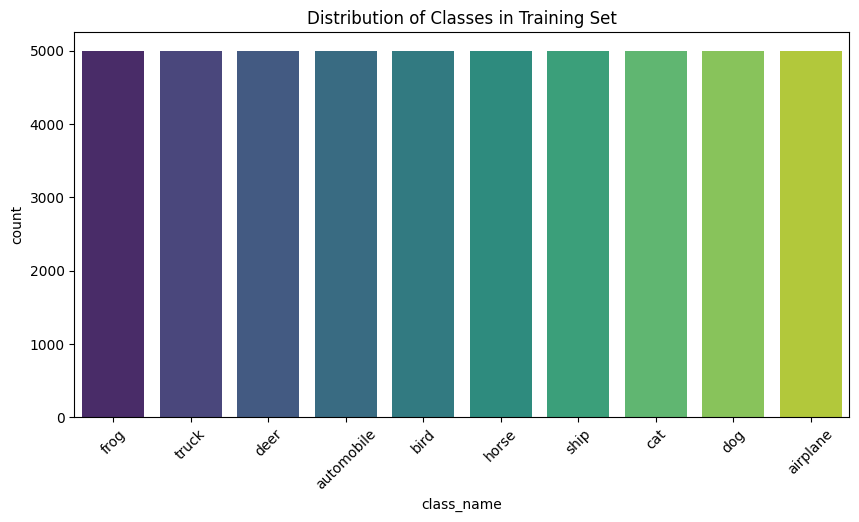

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

label_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Create a DataFrame for easy plotting
df_train = pd.DataFrame(y_train, columns=['label'])
df_train['class_name'] = df_train['label'].apply(lambda x: label_names[x])

plt.figure(figsize=(10, 5))
sns.countplot(data=df_train, x='class_name', hue='class_name', palette='viridis', legend=False)
plt.title('Distribution of Classes in Training Set')
plt.xticks(rotation=45)
plt.show()

**Nhận xét từ EDA**:
- Mỗi lớp có đúng 5000 ảnh trong tập train → dataset **hoàn toàn cân bằng**.
- Không cần xử lý class imbalance.

#### 3.3.2. Kiểm tra tính toàn vẹn trực quan

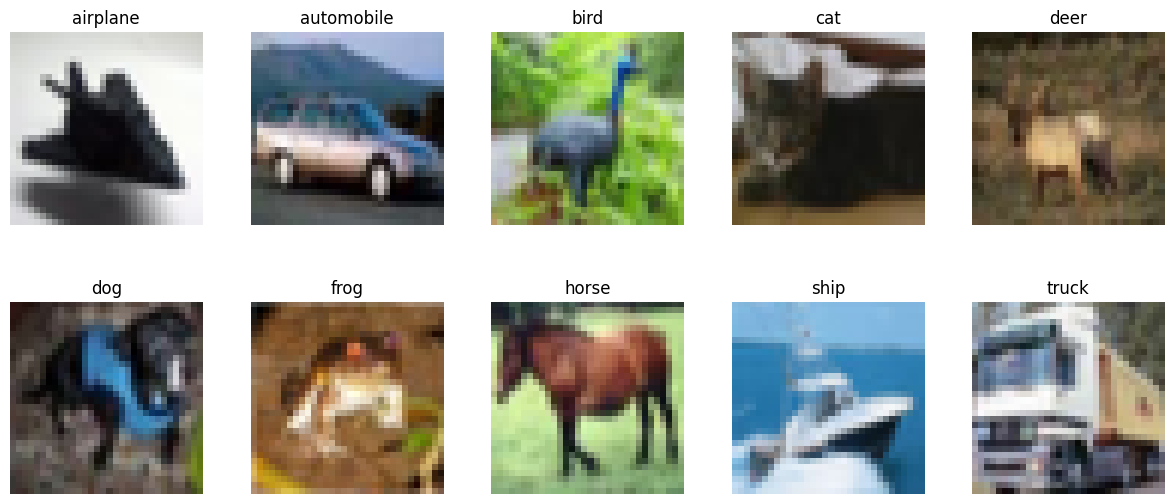

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    # Tìm ảnh đầu tiên của mỗi lớp
    idx = torch.where(y_train == i)[0][0]
    # Chuyển từ (C, H, W) -> (H, W, C) để Matplotlib có thể hiển thị
    img = X_train[idx].permute(1, 2, 0).numpy()

    axes[i].imshow(img)
    axes[i].set_title(label_names[i])
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.4)
plt.show()

#### 3.3.3. Phân tích phân phối pixel theo từng kênh màu (RGB)

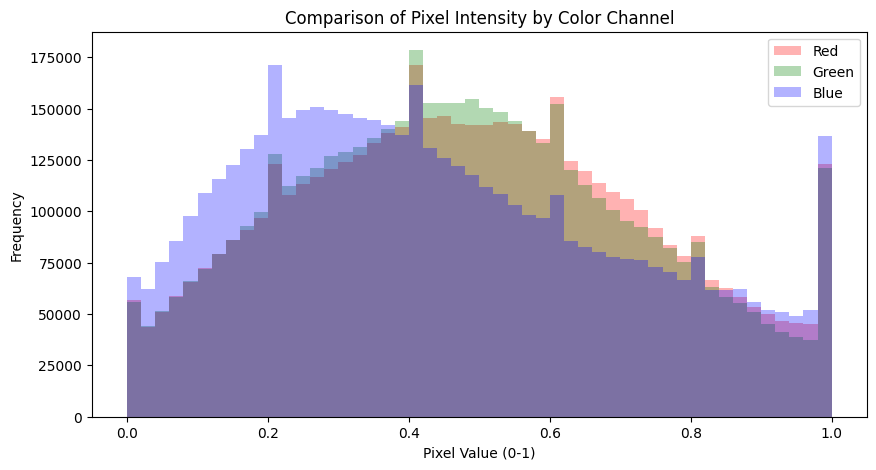

Red Channel - Mean: 0.4886, Std: 0.2466
Green Channel - Mean: 0.4807, Std: 0.2433
Blue Channel - Mean: 0.4461, Std: 0.2620


In [14]:
# Sample for speed
sample_idx = np.random.choice(len(X_train), 5000)
sample_data = X_train[sample_idx] # Shape (5000, 3, 32, 32)

plt.figure(figsize=(10, 5))
# Plot Red, Green, and Blue distributions
# PyTorch: [N, C, H, W] -> C=0: Red, C=1: Green, C=2: Blue
plt.hist(sample_data[:, 0, :, :].flatten().numpy(), bins=50, color='red', alpha=0.3, label='Red')
plt.hist(sample_data[:, 1, :, :].flatten().numpy(), bins=50, color='green', alpha=0.3, label='Green')
plt.hist(sample_data[:, 2, :, :].flatten().numpy(), bins=50, color='blue', alpha=0.3, label='Blue')

plt.legend()
plt.title("Comparison of Pixel Intensity by Color Channel")
plt.xlabel("Pixel Value (0-1)")
plt.ylabel("Frequency")
plt.show()

# Calculate mean and std for each channel (dim 0, 2, 3 are N, H, W)
mean = sample_data.mean(dim=(0, 2, 3))
std = sample_data.std(dim=(0, 2, 3))

# Print specific stats for your report
for i, color in enumerate(['Red', 'Green', 'Blue']):
    print(f"{color} Channel - Mean: {mean[i]:.4f}, Std: {std[i]:.4f}")

### 3.4. Tiền xử lý dữ liệu (Data Preprocessing)
**Các bước chính**:
- Chuẩn hóa pixel về khoảng `[0, 1]`
- One-hot encoding nhãn
- Phân tách tập validation (80/20)
- Data Augmentation (Standard)


In [15]:
from torch.utils.data import DataLoader, TensorDataset, random_split

X_train_norm = X_train.float() / 255.0 if X_train.max() > 1.0 else X_train.float()
X_test_norm = X_test.float() / 255.0 if X_test.max() > 1.0 else X_test.float()
# 1. Tạo Dataset
full_train_dataset = TensorDataset(X_train_norm, y_train)
test_dataset = TensorDataset(X_test_norm, y_test)

# 2. Phân tách tập Validation (80/20)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Preprocessing Complete (PyTorch).")
print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}, Test samples: {len(test_dataset)}")

Preprocessing Complete (PyTorch).
Train samples: 40000, Val samples: 10000, Test samples: 10000


Vì hình ảnh CIFAR-10 có độ phân giải thấp, mô hình rất dễ bị "overfitting". Vì vậy, nhóm sử dụng `ImageDataGenerator` để thực hiện các phép biến đổi ngẫu nhiên ngay trong quá trình huấn luyện.

In [16]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Định nghĩa các bước Augmentation (Xoay, Cắt, Normalize Mean/Std)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(15),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Đưa về dải quanh số 0
])

test_transform = transforms.Compose([
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Lớp bọc để áp dụng Transform vào TensorDataset
class AugmentedDataset(Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.dataset[index]
        if self.transform: x = self.transform(x)
        return x, y
    def __len__(self): return len(self.dataset)

# KHỞI TẠO DATALOADER (Thấy rõ Loader ở đây)
train_loader = DataLoader(AugmentedDataset(train_dataset, train_transform), batch_size=64, shuffle=True)
val_loader = DataLoader(AugmentedDataset(val_dataset, test_transform), batch_size=64, shuffle=False)
test_loader = DataLoader(AugmentedDataset(test_dataset, test_transform), batch_size=64, shuffle=False)

print("✅ Đã chuẩn hóa 0-1, thiết lập Augmentation và khởi tạo DataLoader thành công!")

✅ Đã chuẩn hóa 0-1, thiết lập Augmentation và khởi tạo DataLoader thành công!


**Kiểm tra trực quan sau tiền xử lý (Final Sanity Check)**

Bước này đảm bảo rằng sau tất cả các bước tải, tái cấu trúc, chuẩn hóa và mã hóa, dữ liệu vẫn giữ được ý nghĩa logic.

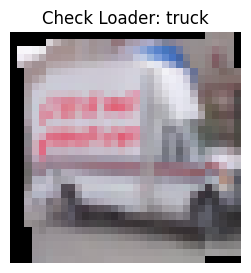

Pixel Range in Loader: [-1.00, 0.97]
Image Shape: torch.Size([3, 32, 32])


In [17]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Lấy 1 batch dữ liệu từ train_loader
data_iter = iter(train_loader)
images, labels = next(data_iter)

# 2. Chọn ảnh đầu tiên trong batch để hiển thị
img = images[0]
label = labels[0].item()

# 3. Vì chúng ta đã Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
# nên ảnh hiện tại đang ở dải [-1, 1]. Cần đưa về [0, 1] để plt.imshow hiển thị đúng màu.
img_display = img * 0.5 + 0.5  # Công thức ngược của Normalize
img_display = img_display.permute(1, 2, 0).numpy() # Chuyển từ (C, H, W) sang (H, W, C)

# 4. Hiển thị
label_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(5, 3))
plt.imshow(np.clip(img_display, 0, 1)) # Clip để đảm bảo không bị lỗi dải màu
plt.title(f"Check Loader: {label_names[label]}")
plt.axis('off')
plt.show()

# 5. Kiểm tra giá trị Pixel thực tế mô hình nhận được (đã chuẩn hóa quanh 0)
print(f"Pixel Range in Loader: [{img.min():.2f}, {img.max():.2f}]")
print(f"Image Shape: {img.shape}") # Nên là [3, 32, 32]

## 4. Xây dựng và Huấn luyện Các Mô hình

Trong phần này, chúng ta sẽ tiến hành xây dựng và so sánh hiệu năng của các mô hình phân loại trên tập dữ liệu CIFAR-10. Để đánh giá toàn diện, 8 tổ hợp thử nghiệm sẽ được thực hiện dựa trên các yếu tố:
1. **Kiến trúc mô hình:** ResNet50 và Simple Vision Transformer (ViT).
2. **Dữ liệu huấn luyện:** Standard Augmentation.
3. **Tham số huấn luyện:** Thống nhất epoch 20, batch size 64, learning rate được chọn riêng theo từng kiến trúc vì scale gradient khác nhau; các hyperparameter còn lại được giữ cố định để đảm bảo tính công bằng trong so sánh.

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# 1. Các thông số cấu hình chung
BATCH_SIZE = 64
num_classes = 10
# Lưu ý: PyTorch sử dụng (Channels, Height, Width)
input_shape = (3, 32, 32)

# 2. Sử dụng các DataLoader đã khởi tạo ở mục 3.4
# train_loader: Chứa dữ liệu train đã được split
# val_loader: Chứa dữ liệu validation
# test_loader: Chứa dữ liệu test

print(f"Huấn luyện sẽ được thực hiện trên các DataLoader PyTorch.")
print(f"Batch size: {BATCH_SIZE}")
print(f"Số lượng lớp: {num_classes}")

Huấn luyện sẽ được thực hiện trên các DataLoader PyTorch.
Batch size: 64
Số lượng lớp: 10


### 4.1 Định nghĩa Kiến trúc Mô hình (Đánh giá trên thiết lập Train From Scratch)

Mục tiêu của phần này là quan sát cách các cơ chế học (inductive bias) khác nhau xử lý dữ liệu ảnh khi không có tri thức vay mượn từ bên ngoài:

1. **Softmax Regression**: Baseline tuyến tính thuần túy.
2. **MLP (Deep & Wide)**: Phá vỡ ảnh thành vector phẳng và dùng các lớp Fully Connected. Kiểm tra xem phi tuyến có thể bù đắp được việc mất cấu trúc không gian 2D hay không.
3. **ResNet50**: Đại diện cho CNN. Sử dụng các bộ lọc tích chập (Convolution) có tính bất biến dịch chuyển và cục bộ (locality). Ở đây, stem layer (conv1) được sửa lại thành kernel 3x3 (thay vì 7x7) và bỏ MaxPool để không làm mất thông tin của ảnh độ phân giải thấp 32x32.
4. **SimpleViT**: Đại diện cho kiến trúc thuần Attention. Cắt ảnh thành các patch 4x4 (không trùng lặp), cộng Positional Encoding và đưa qua Transformer Encoder. Mô hình này hoàn toàn không có bias về không gian (spatial bias) như CNN.

In [25]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T

# --- 1. Softmax Regression Model (High-Stability Version) ---
class SoftmaxRegression(nn.Module):
    def __init__(self, num_classes=10):
        super(SoftmaxRegression, self).__init__()
        self.flatten = nn.Flatten()
        # Sử dụng BatchNorm mạnh hơn để xử lý input thô
        self.bn = nn.BatchNorm1d(3 * 32 * 32, eps=1e-5, momentum=0.1)
        self.linear = nn.Linear(3 * 32 * 32, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.bn(x)
        return self.linear(x)

def build_softmax_model(num_classes=10):
    return SoftmaxRegression(num_classes)

# --- 2. MLP Model (Deep & Wide Architecture) ---
class MLPModel(nn.Module):
    def __init__(self, num_classes=10):
        super(MLPModel, self).__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(3 * 32 * 32, 2048),
            nn.BatchNorm1d(2048),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

def build_mlp_model(num_classes=10):
    return MLPModel(num_classes)

# --- 3. ResNet50 & ViT Models (Giữ nguyên) ---
def build_resnet50_model(num_classes=10, pretrained=True, freeze_backbone=True):
    weights = models.ResNet50_Weights.DEFAULT if pretrained else None
    model = models.resnet50(weights=weights)
    if freeze_backbone:
        for param in model.parameters(): param.requires_grad = False
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(nn.Linear(num_ftrs, 512), nn.ReLU(), nn.Dropout(0.5), nn.Linear(512, num_classes))
    return model

class CIFARResNet50(nn.Module):
    def __init__(self, num_classes=10):
        super(CIFARResNet50, self).__init__()
        self.resnet = models.resnet50(weights=None)
        self.resnet.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.resnet.bn1 = nn.BatchNorm2d(64)
        self.resnet.relu = nn.ReLU(inplace=True)
        self.resnet.maxpool = nn.Identity()
        num_ftrs = self.resnet.fc.in_features
        self.resnet.fc = nn.Linear(num_ftrs, num_classes)
    def forward(self, x): return self.resnet(x)

def build_resnet50_cifar(num_classes=10): return CIFARResNet50(num_classes)

# --- 4. Simple ViT (tự xây bằng nn.TransformerEncoderLayer) ---
class SimpleViT(nn.Module):
    """
    Vision Transformer tự xây theo yêu cầu:
      - Patch Embedding: Conv2d (non-overlapping patches)
      - Positional Encoding: learnable
      - CLS Token
      - TransformerEncoder (dùng nn.TransformerEncoderLayer)
      - Classification Head
    """
    def __init__(
        self,
        img_size=32,
        patch_size=4,       # 32/4 = 8x8 = 64 patches
        in_channels=3,
        num_classes=10,
        embed_dim=128,
        num_heads=4,
        num_layers=6,
        mlp_dim=256,
        dropout=0.1
    ):
        super(SimpleViT, self).__init__()

        assert img_size % patch_size == 0, "img_size phải chia hết cho patch_size"
        num_patches = (img_size // patch_size) ** 2
        patch_dim   = in_channels * patch_size * patch_size  # 3*4*4 = 48

        # ── 1. Patch Embedding ─────────────────────────────────────────
        # Dùng Conv2d với kernel=patch_size, stride=patch_size
        # → tương đương flatten non-overlapping patches rồi linear project
        self.patch_embed = nn.Sequential(
            nn.Conv2d(in_channels, embed_dim,
                      kernel_size=patch_size, stride=patch_size),
            nn.Flatten(2)   # (B, embed_dim, num_patches) 
        )

        # ── 2. CLS Token ───────────────────────────────────────────────
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        # ── 3. Positional Encoding (learnable) ────────────────────────
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        self.pos_dropout = nn.Dropout(dropout)

        # ── 4. Transformer Encoder ────────────────────────────────────
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=mlp_dim,
            dropout=dropout,
            activation='gelu',
            batch_first=True,   # input shape: (B, seq, dim)
            norm_first=True     # Pre-LN: ổn định hơn khi train from scratch
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
            norm=nn.LayerNorm(embed_dim)
        )

        # ── 5. Classification Head ─────────────────────────────────────
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        B = x.shape[0]

        # Patch Embedding: (B, C, H, W) → (B, embed_dim, num_patches)
        x = self.patch_embed(x)          # (B, embed_dim, num_patches)
        x = x.transpose(1, 2)            # (B, num_patches, embed_dim)

        # Prepend CLS token
        cls = self.cls_token.expand(B, -1, -1)   # (B, 1, embed_dim)
        x   = torch.cat([cls, x], dim=1)          # (B, num_patches+1, embed_dim)

        # Positional Encoding
        x = self.pos_dropout(x + self.pos_embed)

        # Transformer Encoder
        x = self.transformer(x)          # (B, num_patches+1, embed_dim)

        # Lấy CLS token để classify
        cls_out = x[:, 0]                # (B, embed_dim)
        return self.head(cls_out)        # (B, num_classes)


def build_vit_model(num_classes=10):
    return SimpleViT(
        img_size=32, patch_size=4,
        embed_dim=128, num_heads=4,
        num_layers=6, mlp_dim=256,
        dropout=0.1, num_classes=num_classes
    )

print("Kiến trúc MLP đã được nâng cấp lên Deep & Wide để cải thiện độ chính xác.")

Kiến trúc MLP đã được nâng cấp lên Deep & Wide để cải thiện độ chính xác.


In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.auto import tqdm
import copy
def train_and_evaluate_model(model, train_loader, val_loader, test_loader, model_name,
                             epochs=50,
                             initial_lr=1e-4,
                             weight_decay=0.05,
                             label_smoothing=0.1):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # 1. Loss function & Optimizer
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = optim.AdamW(model.parameters(), lr=initial_lr, weight_decay=weight_decay)

    # 2. Scheduler: Cosine Annealing
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print(f"\n{'-'*15} Training {model_name} on {device} {'-'*15}")

    for epoch in range(epochs):
        # --- Training Phase ---
        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            loss.backward() # Bước Backward quan trọng
            optimizer.step() # Bước Cập nhật tham số

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        scheduler.step()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)

        # --- Validation Phase ---
        model.eval()
        val_loss = 0.0
        val_corrects = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)

        val_epoch_loss = val_loss / len(val_loader.dataset)
        val_epoch_acc = val_corrects.double() / len(val_loader.dataset)

        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc.item())
        history['val_loss'].append(val_epoch_loss)
        history['val_acc'].append(val_epoch_acc.item())

        print(f"Epoch {epoch+1:02d}: Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | Val Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.4f}")

        if val_epoch_acc > best_acc:
            best_acc = val_epoch_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(best_model_wts, f"{model_name}_best.pth")

    # --- Final Evaluation on Test Set ---
    model.load_state_dict(best_model_wts)
    model.eval()
    test_corrects = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            test_corrects += torch.sum(preds == labels.data)

    test_acc = test_corrects.double() / len(test_loader.dataset)
    print(f"\n=> Final Test Accuracy for {model_name}: {test_acc:.4f}")

    return history, test_acc.item()

In [29]:

EPOCHS_BASE = 20
SHARED_CONFIG = dict(
    epochs         = EPOCHS_BASE,
    weight_decay   = 1e-4,
    label_smoothing= 0.1,
)
# lr riêng vì scale gradient khác nhau giữa linear và deep model
LR_MAP = {
    "Softmax_StandardAug": 1e-3,
    "MLP_StandardAug":     5e-4,
    "ResNet50":            1e-4,
    "SimpleViT":           1e-4,
}

results = {}

# ==================== RESNET50 ====================
# 1. ResNet50
model_name = "ResNet50"

# Khởi tạo mô hình (pretrained=True, freeze_backbone=True)
rasnet50 = build_resnet50_cifar(num_classes=10)

# Huấn luyện sử dụng DataLoader đã chuẩn bị
history, test_acc = train_and_evaluate_model(
    rasnet50,
    train_loader,
    val_loader,
    test_loader,
    model_name,
    initial_lr=LR_MAP[model_name],
    **SHARED_CONFIG
)

results[model_name] = {'history': history, 'test_accuracy': test_acc}


--------------- Training ResNet50 on cuda ---------------


Epoch 1/20:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 01: Train Loss: 1.9766 Acc: 0.3012 | Val Loss: 1.7800 Acc: 0.4012


Epoch 2/20:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 02: Train Loss: 1.7260 Acc: 0.4278 | Val Loss: 1.6067 Acc: 0.4922


...

Epoch 18: Train Loss: 0.9073 Acc: 0.8266 | Val Loss: 0.9821 Acc: 0.7905


Epoch 19/20:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 19: Train Loss: 0.8981 Acc: 0.8314 | Val Loss: 0.9765 Acc: 0.7943


Epoch 20/20:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 20: Train Loss: 0.8932 Acc: 0.8344 | Val Loss: 0.9756 Acc: 0.7920

=> Final Test Accuracy for ResNet50: 0.7905


In [31]:
model_name = "SimpleViT"

vit_frozen = build_vit_model(num_classes=10)

# Huấn luyện sử dụng DataLoader đã chuẩn bị
history, test_acc = train_and_evaluate_model(
    vit_frozen,
    train_loader,
    val_loader,
    test_loader,
    model_name,
    initial_lr=LR_MAP[model_name],
    **SHARED_CONFIG
)

results[model_name] = {'history': history, 'test_accuracy': test_acc}


--------------- Training SimpleViT on cuda ---------------


/tmp/ipykernel_921/3258087188.py:139: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Epoch 1/20:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 01: Train Loss: 1.9847 Acc: 0.2867 | Val Loss: 1.9574 Acc: 0.3185


Epoch 2/20:   0%|          | 0/625 [00:00<?, ?it/s]

...

Epoch 18: Train Loss: 1.4265 Acc: 0.5707 | Val Loss: 1.3846 Acc: 0.5915


Epoch 19/20:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 19: Train Loss: 1.4194 Acc: 0.5756 | Val Loss: 1.3812 Acc: 0.5939


Epoch 20/20:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 20: Train Loss: 1.4171 Acc: 0.5797 | Val Loss: 1.3881 Acc: 0.5898

=> Final Test Accuracy for SimpleViT: 0.5775


In [32]:
# 3. Softmax Regression - Standard Aug
model_name = "Softmax_StandardAug"

# Khởi tạo mô hình Softmax
softmax_model = build_softmax_model(num_classes=10)

# Huấn luyện
history, test_acc = train_and_evaluate_model(
    softmax_model,
    train_loader,
    val_loader,
    test_loader,
    model_name,
    initial_lr=LR_MAP[model_name],
    **SHARED_CONFIG
)

results[model_name] = {'history': history, 'test_accuracy': test_acc}


--------------- Training Softmax_StandardAug on cuda ---------------


Epoch 1/20:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 01: Train Loss: 2.2123 Acc: 0.2585 | Val Loss: 2.2073 Acc: 0.2827


Epoch 2/20:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 02: Train Loss: 2.1621 Acc: 0.2738 | Val Loss: 2.1747 Acc: 0.2904


...

Epoch 18: Train Loss: 1.9714 Acc: 0.3426 | Val Loss: 1.9111 Acc: 0.3747


Epoch 19/20:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 19: Train Loss: 1.9685 Acc: 0.3442 | Val Loss: 1.9086 Acc: 0.3779


Epoch 20/20:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 20: Train Loss: 1.9691 Acc: 0.3435 | Val Loss: 1.9055 Acc: 0.3828

=> Final Test Accuracy for Softmax_StandardAug: 0.3851


In [33]:
# 4. MLP - Standard Aug
model_name = "MLP_StandardAug"

# Khởi tạo mô hình MLP
mlp_model = build_mlp_model(num_classes=10)

# Huấn luyện
history, test_acc = train_and_evaluate_model(
    mlp_model,
    train_loader,
    val_loader,
    test_loader,
    model_name,
    initial_lr=LR_MAP[model_name],
    **SHARED_CONFIG
)

results[model_name] = {'history': history, 'test_accuracy': test_acc}


--------------- Training MLP_StandardAug on cuda ---------------


Epoch 1/20:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 01: Train Loss: 1.9845 Acc: 0.3041 | Val Loss: 1.8253 Acc: 0.3807


Epoch 2/20:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 02: Train Loss: 1.8689 Acc: 0.3644 | Val Loss: 1.7411 Acc: 0.4238


...

Epoch 18: Train Loss: 1.6114 Acc: 0.4864 | Val Loss: 1.4901 Acc: 0.5463


Epoch 19/20:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 19: Train Loss: 1.6098 Acc: 0.4880 | Val Loss: 1.4899 Acc: 0.5482


Epoch 20/20:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 20: Train Loss: 1.6049 Acc: 0.4916 | Val Loss: 1.4891 Acc: 0.5489

=> Final Test Accuracy for MLP_StandardAug: 0.5427


In [34]:
def run_experiments_and_compare(models_dict, train_loader, val_loader, test_loader, epochs=50):
    all_histories = {}
    test_results = {}

    # Huấn luyện lần lượt các mô hình
    for model_name, model in models_dict.items():
        history, test_acc = train_and_evaluate_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            test_loader=test_loader,
            model_name=model_name,
            epochs=epochs
        )
        all_histories[model_name] = history
        test_results[model_name] = test_acc

    # --- Trình bày kết quả: Vẽ biểu đồ ---
    plt.figure(figsize=(16, 6))

    # Biểu đồ Accuracy
    plt.subplot(1, 2, 1)
    for model_name, history in all_histories.items():
        plt.plot(history['val_acc'], label=f'{model_name}')
    plt.title('Validation Accuracy Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # Biểu đồ Loss
    plt.subplot(1, 2, 2)
    for model_name, history in all_histories.items():
        plt.plot(history['val_loss'], label=f'{model_name}')
    plt.title('Validation Loss Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.savefig('models_comparison_chart.png')
    plt.show()

    # --- Trình bày kết quả: Bảng số liệu khoa học ---
    df_results = pd.DataFrame(list(test_results.items()), columns=['Mô hình', 'Test Accuracy'])
    df_results = df_results.sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)

    print("\n" + "="*40)
    print("BẢNG TỔNG HỢP KẾT QUẢ TEST ACCURACY")
    print("="*40)
    print(df_results.to_markdown(index=False))
    print("="*40)

    return all_histories, df_results

/tmp/ipykernel_921/3258087188.py:139: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


--- ĐANG NẠP TRỌNG SỐ VÀ ĐÁNH GIÁ MÔ HÌNH ---
✓ Softmax_Regression: Loaded and Evaluated. Test Acc: 0.3851
✓ MLP_Deep_Wide: Loaded and Evaluated. Test Acc: 0.5427
✓ ResNet50_FullTrain: Loaded and Evaluated. Test Acc: 0.7905
✓ SimpleViT: Loaded and Evaluated. Test Acc: 0.5775

BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST (CIFAR-10)


,Mô hình (Model Architecture),Độ chính xác (Test Accuracy)
0,ResNet50_FullTrain,0.790500
1,SimpleViT,0.577500
2,MLP_Deep_Wide,0.542700
3,Softmax_Regression,0.385100


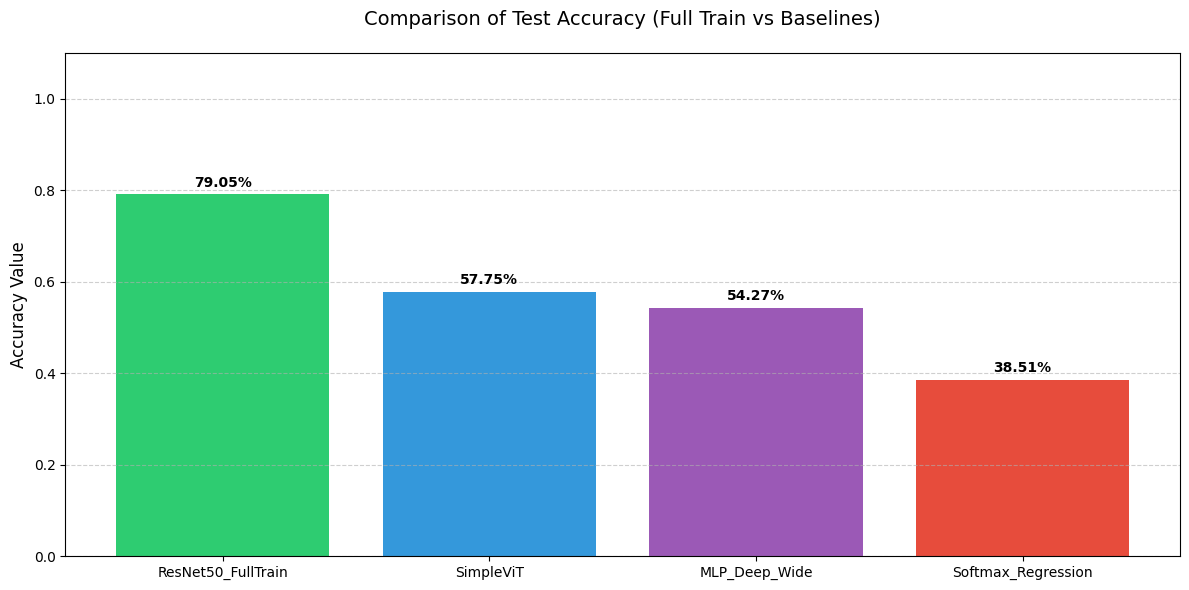

In [43]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import torch

# 1. Khởi tạo lại các kiến trúc mô hình để đánh giá
models_to_compare = {
    "Softmax_Regression": build_softmax_model(num_classes=10),
    "MLP_Deep_Wide": build_mlp_model(num_classes=10),
    "ResNet50_FullTrain": build_resnet50_cifar(num_classes=10), # ResNet50 đã được build với requires_grad=True mặc định trong CIFARResNet50
    "SimpleViT": build_vit_model(num_classes=10)
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_results = {}

print("--- ĐANG NẠP TRỌNG SỐ VÀ ĐÁNH GIÁ MÔ HÌNH ---")

# Map correct weight filenames saved during previous training steps
weight_map = {
    "Softmax_Regression": "Softmax_StandardAug_best.pth",
    "MLP_Deep_Wide": "MLP_StandardAug_best.pth",
    "ResNet50_FullTrain": "ResNet50_best.pth",
    "SimpleViT": "SimpleViT_best.pth"
}

for name, model in models_to_compare.items():
    weight_path = weight_map.get(name)

    if os.path.exists(weight_path):
        model.load_state_dict(torch.load(weight_path, map_location=device))
        model.to(device)
        model.eval()

        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()

        acc = correct / total
        test_results[name] = acc
        print(f"✓ {name}: Loaded and Evaluated. Test Acc: {acc:.4f}")
    else:
        print(f"✗ {name}: File {weight_path} không tồn tại.")

# 2. Hiển thị kết quả dưới dạng bảng khoa học
if test_results:
    df_summary = pd.DataFrame(list(test_results.items()), columns=['Mô hình (Model Architecture)', 'Độ chính xác (Test Accuracy)'])
    df_summary = df_summary.sort_values(by='Độ chính xác (Test Accuracy)', ascending=False).reset_index(drop=True)

    print("\n" + "="*60)
    print("BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST (CIFAR-10)")
    print("="*60)
    display(df_summary.style.background_gradient(cmap='YlGn'))

    # 3. Vẽ biểu đồ so sánh
    plt.figure(figsize=(12, 6))
    colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']
    bars = plt.bar(df_summary['Mô hình (Model Architecture)'], df_summary['Độ chính xác (Test Accuracy)'], color=colors[:len(df_summary)])

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2%}', ha='center', va='bottom', fontweight='bold')

    plt.title("Comparison of Test Accuracy (Full Train vs Baselines)", fontsize=14, pad=20)
    plt.ylabel("Accuracy Value", fontsize=12)
    plt.ylim(0, 1.1)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.savefig("test_acc_comparison_4models.png", dpi=150, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

def plot_all_confusion_matrices(models_dict, test_loader, device, label_names):
    num_models = len(models_dict)
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    axes = axes.ravel()

    for idx, (name, model) in enumerate(models_dict.items()):
        all_preds = []
        all_labels = []
        
        model.to(device)
        model.eval()
        
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        # Tính toán ma trận nhầm lẫn
        cm = confusion_matrix(all_labels, all_preds)
        
        # Vẽ Heatmap
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                    xticklabels=label_names, yticklabels=label_names, cbar=False)
        
        axes[idx].set_title(f'Confusion Matrix: {name}', fontsize=16, fontweight='bold')
        axes[idx].set_xlabel('Predicted Label', fontsize=12)
        axes[idx].set_ylabel('True Label', fontsize=12)

    plt.savefig("confusion_maxtrix_4models.png", dpi=150, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

plot_all_confusion_matrices(models_to_compare, test_loader, device, label_names)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

MODEL_STYLES = {
    "Softmax_StandardAug": {"color": "#e74c3c", "ls": "--",  "marker": "o"},
    "MLP_StandardAug":     {"color": "#f39c12", "ls": "-.",  "marker": "s"},
    "ResNet50":            {"color": "#2ecc71", "ls": "-",   "marker": "^"},
    "SimpleViT":           {"color": "#3498db", "ls": "-",   "marker": "D"},
}

DISPLAY_NAMES = {
    "Softmax_StandardAug": "Softmax Regression",
    "MLP_StandardAug":     "MLP Deep & Wide",
    "ResNet50":            "ResNet50 (CIFAR)",
    "SimpleViT":              "SimpleViT",
}

# ── Lấy history từ dict results đã có ────────────────────────────────────────
# results = { model_name: { 'history': {...}, 'test_accuracy': float } }
histories = {k: v['history'] for k, v in results.items()}

# ── Hàm vẽ 1 subplot ─────────────────────────────────────────────────────────
def plot_metric(ax, histories, metric_key, title, ylabel, smooth_window=1):
    def smooth(y, w):
        if w <= 1 or len(y) < w:
            return y
        kernel = np.ones(w) / w
        return np.convolve(y, kernel, mode='valid')

    for name, history in histories.items():
        if metric_key not in history:
            continue
        style = MODEL_STYLES.get(name, {})
        y = history[metric_key]
        ys = smooth(y, smooth_window)
        xs = range(len(ys))
        ax.plot(
            xs, ys,
            label=DISPLAY_NAMES.get(name, name),
            color=style.get("color", None),
            linestyle=style.get("ls", "-"),
            linewidth=1.8,
            alpha=0.92
        )

    ax.set_title(title, fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel("Epoch", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(fontsize=8, loc='best', framealpha=0.85)
    ax.grid(True, linestyle='--', alpha=0.45)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.spines[['top', 'right']].set_visible(False)


# ── Vẽ 4 biểu đồ trên 1 figure ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    "Training History – CIFAR-10  |  4 Mô hình So sánh",
    fontsize=15, fontweight='bold', y=1.01
)

SMOOTH = 1

plot_metric(axes[0, 0], histories, "train_loss",
            "Train Loss",          "Loss",     smooth_window=SMOOTH)

plot_metric(axes[0, 1], histories, "train_acc",
            "Train Accuracy",      "Accuracy", smooth_window=SMOOTH)

plot_metric(axes[1, 0], histories, "val_loss",
            "Validation Loss",     "Loss",     smooth_window=SMOOTH)

plot_metric(axes[1, 1], histories, "val_acc",
            "Validation Accuracy", "Accuracy", smooth_window=SMOOTH)

# Highlight best val_acc epoch cho mỗi mô hình (subplot ④)
ax_va = axes[1, 1]
for name, history in histories.items():
    if 'val_acc' not in history:
        continue
    best_ep = int(np.argmax(history['val_acc']))
    best_val = history['val_acc'][best_ep]
    style = MODEL_STYLES.get(name, {})
    ax_va.annotate(
        f"{best_val:.3f}",
        xy=(best_ep, best_val),
        xytext=(best_ep + 0.4, best_val - 0.015),
        fontsize=7,
        color=style.get("color", "black"),
        arrowprops=dict(arrowstyle='->', color=style.get("color", "gray"), lw=1)
    )

plt.tight_layout()
plt.savefig("training_history_4models.png", dpi=150, bbox_inches='tight')
plt.show()

# ── In bảng tóm tắt nhanh ────────────────────────────────────────────────────
print("\n{'─'*62}")
print(f"{'Model':<26} {'Best Val Acc':>12} {'Final Val Acc':>14} {'Test Acc':>10}")
print('─'*62)
for name, data in results.items():
    h = data['history']
    best_v  = max(h['val_acc'])
    final_v = h['val_acc'][-1]
    test_a  = data['test_accuracy']
    print(f"{DISPLAY_NAMES.get(name, name):<26} {best_v:>12.4f} {final_v:>14.4f} {test_a:>10.4f}")
print('─'*62)

### 4.2. Nhận xét và Phân tích kết quả thực nghiệm

Dựa trên biểu đồ Training History, ma trận nhầm lẫn và Test Accuracy thực tế, kết quả phản ánh chính xác bản chất toán học và kiến trúc của từng mô hình khi bị ép huấn luyện từ đầu (from scratch) trên 50,000 ảnh kích thước nhỏ.

**1. ResNet50 (79.05%): Sức mạnh tuyệt đối của Inductive Bias**
* **Tại sao thắng?** Tích chập (Convolution) bản chất đã mang sẵn giả định về "tính cục bộ" (pixels gần nhau có liên quan đến nhau) và "bất biến dịch chuyển" (con mèo ở góc nào cũng là con mèo). Do đó, ResNet50 học các đặc trưng không gian (cạnh, góc, texture) cực kỳ hiệu quả mà không cần quá nhiều dữ liệu. 
* **Phân tích Confusion Matrix:** Các nhãn bị nhầm lẫn nhiều nhất là `Cat` vs `Dog` (172/129) và `Automobile` vs `Truck` (64/39). Đây là giới hạn về semantic ở độ phân giải 32x32, hình dáng tai thú hay cabin xe bị mờ nhòe khiến ngay cả CNN cũng khó phân tách. Biểu đồ lịch sử huấn luyện cho thấy val_loss của ResNet50 giảm ổn định nhất, minh chứng cho sự tối ưu mượt mà của skip-connection.

**2. SimpleViT (57.75%): Nạn nhân của sự thiếu hụt dữ liệu (Data-Hungry)**
* **Tại sao thất bại thảm hại?** Trái với ảo tưởng về sức mạnh của Transformer, ViT hoạt động cực tệ khi train từ đầu trên dataset nhỏ. ViT coi bức ảnh như một *chuỗi các từ* (patches), nó không hề biết patch số 1 nằm cạnh patch số 2. Nó phải tự học lại định nghĩa về "không gian 2D" từ con số 0 thông qua cơ chế Self-Attention. 50,000 ảnh CIFAR-10 là quá ít để Attention map hội tụ được cấu trúc vật lý của vạn vật.
* **Bằng chứng:** Biểu đồ val_acc của SimpleViT đi ngang (plateau) rất sớm từ epoch thứ 9 ở mức ~55-57%. Cột dự đoán trong Confusion Matrix phân tán diện rộng, chứng tỏ mô hình đang "đoán mò" ở nhiều nhãn (VD: dự đoán sai `Bird` thành `Deer` 152 lần, `Cat` thành `Dog` 334 lần).

**3. MLP Deep & Wide (54.27%) & Softmax Regression (38.51%): Mù lòa về không gian**
* **MLP:** Mặc dù sâu và rộng, việc dùng lệnh `Flatten()` ngay từ đầu đã tàn phá toàn bộ cấu trúc không gian của bức ảnh. Mạng nơ-ron chỉ đang cố học thuộc các mẫu pixel tĩnh. Kết quả 54.27% cho thấy phi tuyến (ReLU) có giúp tìm ra một số pattern mờ nhạt, nhưng hoàn toàn vô vọng trước các phép biến đổi hình học cơ bản.
* **Softmax:** Với 38.51%, mô hình chỉ tốt hơn việc đoán mò ngẫu nhiên (10%) một chút. Đa tạp (manifold) hình ảnh thực tế là một hàm phi tuyến phức tạp bậc cao, một ranh giới siêu phẳng (hyperplane) tuyến tính không thể nào chia tách được 10 class này.

**Kết luận:**
Thực nghiệm chứng minh rõ ràng: Trừ phi ta có hàng chục triệu ảnh (hoặc sử dụng Pre-trained weights), không nên sử dụng Vision Transformer. Với các bài toán dữ liệu nhỏ và vừa, CNN mang sẵn inductive bias ưu việt vẫn là chân lý không thể lật đổ.